In [1]:
# Importar las bibliotecas necesarias
import LanusStats as ls
from LanusStats.functions import get_available_pages, get_available_leagues, get_available_season_for_leagues
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones de visualización
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

# Ver las fuentes disponibles
pages = get_available_pages()
print(f"Fuentes disponibles: {pages}")

# Explorar ligas disponibles en cada fuente
for page in pages:
    print(f"\nLigas disponibles en {page}:")
    try:
        leagues = get_available_leagues(page)
        for league in leagues:
            if 'MX' in league or 'Mexico' in league:
                print(f"- {league}")
    except Exception as e:
        print(f"Error: {e}")

Fuentes disponibles: dict_keys(['Fbref', 'Sofascore', '365Scores', 'Fotmob', 'Transfermarkt', 'DataFactory'])

Ligas disponibles en Fbref:
- Liga MX

Ligas disponibles en Sofascore:
- Mexico LigaMX Apertura
- Mexico LigaMX Clausura

Ligas disponibles en 365Scores:

Ligas disponibles en Fotmob:
- Liga MX

Ligas disponibles en Transfermarkt:

Ligas disponibles en DataFactory:


In [2]:
from LanusStats.functions import get_available_pages, get_available_leagues, get_available_season_for_leagues

# Obtener la lista de páginas (fuentes) configuradas
pages = get_available_pages()
print("Fuentes disponibles:", list(pages))

# Recorremos cada fuente y para cada liga disponible mostramos sus temporadas configuradas
for page in pages:
    print("\nFuente:", page)
    try:
        leagues = get_available_leagues(page)
        for league in leagues:
            try:
                # Se utiliza la función get_available_season_for_leagues para extraer la información
                league_data = get_available_season_for_leagues(page, league)
                seasons = league_data.get('seasons', None)
                print(f"  Liga: {league}\n    Temporadas: {seasons}")
            except Exception as e:
                print(f"  No se pudo obtener la información para la liga '{league}': {e}")
    except Exception as e:
        print(f"  No se pudieron listar ligas para la fuente '{page}': {e}")


Fuentes disponibles: ['Fbref', 'Sofascore', '365Scores', 'Fotmob', 'Transfermarkt', 'DataFactory']

Fuente: Fbref
  Liga: Copa de la Liga
    Temporadas: {'2023', '2020', '2022', '2024', '2021', '2025'}
  Liga: Primera Division Argentina
    Temporadas: {'2023', '2022', '2024', '2021', '2025'}
  Liga: Primera Division Uruguay
    Temporadas: {'2023', '2022', '2024', '2021', '2025'}
  Liga: Brasileirao
    Temporadas: {'2023', '2022', '2024', '2021', '2025'}
  Liga: Brasileirao B
    Temporadas: {'2023', '2022', '2024', '2021', '2025'}
  Liga: Primera Division Colombia
    Temporadas: {'2023', '2022', '2024', '2021', '2025'}
  Liga: Primera Division Chile
    Temporadas: {'2023', '2022', '2024', '2021', '2025'}
  Liga: Primera Division Peru
    Temporadas: {'2023', '2022', '2024', '2021', '2025'}
  Liga: Primera Division Venezuela
    Temporadas: {'2023', '2022', '2024', '2021', '2025'}
  Liga: Primera Division Ecuador
    Temporadas: {'2023', '2022', '2024', '2021', '2025'}
  Liga: Pri

In [3]:
from LanusStats.functions import get_available_season_for_leagues

# Obtén la información de la liga "Liga MX" para Fotmob.
liga_mx_data = get_available_season_for_leagues("Fotmob", "Liga MX")
print("ID de la Liga MX en Fotmob:", liga_mx_data.get("id"))
print("Temporadas disponibles para Liga MX en Fotmob:")
print(liga_mx_data.get("seasons"))


ID de la Liga MX en Fotmob: 230
Temporadas disponibles para Liga MX en Fotmob:
{'2016/2017 - Clausura', '2015/2016 - Clausura', '2024/2025 - Apertura', '2023/2024 - Apertura', '2022/2023 - Clausura', '2015/2016 - Apertura', '2023/2024 - Clausura', '2014/2015 - Apertura', '2021/2022 - Clausura', '2014/2015 - Clausura', '2018/2019 - Apertura', '2013/2014 - Apertura', '2017/2018 - Clausura', '2021/2022 - Apertura', '2019/2020 - Apertura', '2017/2018 - Apertura', '2020/2021 - Clausura', '2019/2020 - Clausura', '2022/2023 - Apertura', '2016/2017 - Apertura', '2013/2014 - Clausura', '2020/2021 - Apertura', '2024/2025 - Clausura', '2018/2019 - Clausura'}


This response has a list of two values, because the tables are split. If you save the list in a variable and then do variable[0]["table"] you will have all of the tables
Then just select one ["all", "home", "away", "form", "xg"] that exists and put it inside a pd.DataFrame()
Something like pd.DataFrame(variable[0]["table"]["all"])
Tipo de objeto extraído: <class 'pandas.core.frame.DataFrame'>
Datos brutos (primeras 10 filas):
  ccode  leagueId                                            pageUrl  \
0   MEX    889724  /leagues/889724/overview/clausura?season=2023-...   
1   MEX    885831  /leagues/885831/overview/apertura?season=2023-...   

  leagueName                                             legend  \
0   Clausura  [{'title': 'Qualification next stage', 'tKey':...   
1   Apertura  [{'title': 'Qualification next stage', 'tKey':...   

                                               table ongoing  
0  {'all': [{'name': 'CF America', 'shortName': '...      []  
1  {'all': [{'name': 'CF 

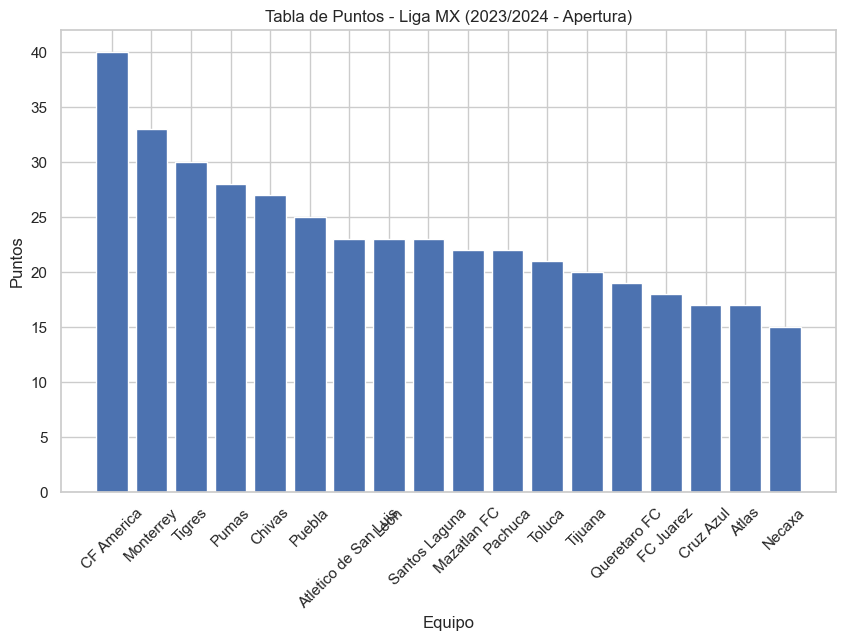

In [4]:
from LanusStats.fotmob import FotMob
import pandas as pd
import matplotlib.pyplot as plt

# Crea la instancia del scraper de FotMob
fotmob = FotMob()

# Define la liga y la temporada a extraer.
# En tu configuración, 'Liga MX' tiene las temporadas en formato lista (sin mapeo a ID),
# por lo que se utiliza la cadena directa para construir la URL.
liga = "Liga MX"
temporada = "2023/2024 - Apertura"

# Extraer la tabla de posiciones utilizando la función get_season_tables
try:
    resultado = fotmob.get_season_tables(liga, temporada, table='all')
except Exception as e:
    print("Error al extraer los datos:", e)
else:
    # Si resultado es una lista, conviértela a DataFrame
    if isinstance(resultado, list):
        df_resultado = pd.DataFrame(resultado)
    else:
        df_resultado = resultado

    print("Tipo de objeto extraído:", type(df_resultado))
    print("Datos brutos (primeras 10 filas):")
    print(df_resultado.head(10))
    
    # Filtrar el registro que contenga la información que buscas.
    # Se espera que en la columna "leagueName" aparezcan valores como "Apertura" y "Clausura"
    registro_apertura = df_resultado[df_resultado['leagueName'] == "Apertura"]
    if registro_apertura.empty:
        print("No se encontró un registro marcado como 'Apertura'. Se utilizará el primer registro:")
        registro = df_resultado.iloc[0]
    else:
        registro = registro_apertura.iloc[0]
    
    # La columna 'table' en este registro es un diccionario que contiene la tabla,
    # con claves como "all", "home", etc. Extraemos la tabla usando la clave "all".
    try:
        tabla_final = pd.DataFrame(registro['table']["all"])
    except Exception as e:
        print("Error al procesar la tabla interna:", e)
    else:
        print("Tabla de posiciones (primeras 10 filas):")
        print(tabla_final.head(10))
        
        # Verifica que la tabla contenga columnas clave, por ejemplo "name" y "pts".
        if "name" in tabla_final.columns and "pts" in tabla_final.columns:
            print("El webscraping se realizó correctamente y la tabla contiene datos reales.")
            
            # Opcional: visualiza un gráfico de barras con los puntos de cada equipo.
            plt.figure(figsize=(10,6))
            plt.bar(tabla_final["name"], tabla_final["pts"])
            plt.title(f"Tabla de Puntos - {liga} ({temporada})")
            plt.xlabel("Equipo")
            plt.ylabel("Puntos")
            plt.xticks(rotation=45)
            plt.show()
        else:
            print("La tabla extraída no contiene las columnas esperadas (por ejemplo, 'name' o 'pts').")


In [5]:
fbref = ls.Fbref()

In [7]:
fbref.possible_stats

['stats',
 'keepers',
 'keepersadv',
 'shooting',
 'passing',
 'passing_types',
 'gca',
 'defense',
 'possession',
 'playingtime',
 'misc']

In [9]:
ls.get_available_leagues('Fbref')

['Copa de la Liga',
 'Primera Division Argentina',
 'Primera Division Uruguay',
 'Brasileirao',
 'Brasileirao B',
 'Primera Division Colombia',
 'Primera Division Chile',
 'Primera Division Peru',
 'Primera Division Venezuela',
 'Primera Division Ecuador',
 'Primera Division Bolivia',
 'Primera Division Paraguay',
 'Brasileirao F',
 'MLS',
 'USL Championship',
 'Premier League',
 'La Liga',
 'Ligue 1',
 'Bundesliga',
 'Serie A',
 'Big 5 European Leagues',
 'Danish Superliga',
 'Eredivise',
 'Primeira Liga Portugal',
 'Copa America',
 'Euros',
 'Saudi League',
 'EFL Championship',
 'La Liga 2',
 'Belgian Pro League',
 'Challenger Pro League',
 '2. Bundesliga',
 'Ligue 2',
 'Serie B',
 'J1 League',
 'NSWL',
 'Wowens Super League',
 'Liga F',
 'Premier Division South Africa',
 'Champions League',
 'Europa League',
 'Conference League',
 'Copa Libertadores',
 'Liga MX']

In [12]:
fbref.get_teams_season_stats('passing','Liga MX', '2024-2025')

Starting to scrape teams data from Fbref...


,Squad,# Pl,90s,Cmp,Att,Cmp%,TotDist,PrgDist,Cmp,Att,Cmp%,Cmp,Att,Cmp%,Cmp,Att,Cmp%,Ast,xAG,xA,A-xAG,KP,1/3,PPA,CrsPA,PrgP
0,América,40,34.0,15174,17976,84.4,270886,97533,6593,7258,90.8,6438,7197,89.5,1636,2554,64.1,48,44.9,41.3,3.1,395,1195,299,54,1424
1,Atlas,31,34.0,10667,13963,76.4,194011,80607,4704,5417,86.8,4525,5449,83.0,1194,2418,49.4,28,25.2,22.2,2.8,295,818,196,70,1000
2,Atlético,33,34.0,14759,17927,82.3,271863,94514,6051,6770,89.4,6714,7538,89.1,1643,2799,58.7,29,25.5,24.2,3.5,295,1172,233,83,1285
3,Cruz Azul,33,34.0,15198,18378,82.7,279372,101366,6324,6989,90.5,6624,7541,87.8,1815,2912,62.3,47,37.8,38.9,9.2,399,1266,376,106,1537
4,FC Juárez,36,34.0,11325,14444,78.4,219133,83211,4322,4967,87.0,5204,6111,85.2,1534,2683,57.2,27,24.5,23.2,2.5,296,903,165,66,1132
5,Guadalajara,38,34.0,12893,16148,79.8,243309,88025,5265,5975,88.1,5829,6740,86.5,1550,2721,57.0,30,31.4,28.2,-1.4,329,1144,234,79,1284
6,León,36,34.0,12024,15155,79.3,234951,91032,4658,5309,87.7,5398,6220,86.8,1705,2912,58.6,33,29.4,26.8,3.6,313,1053,215,75,1111
7,Mazatlán,35,34.0,11344,14549,78.0,213289,84542,4596,5265,87.3,5111,5981,85.5,1372,2510,54.7,13,28.1,27.5,-15.1,276,960,202,52,1156
8,Monterrey,34,34.0,15056,18155,82.9,272788,102379,6525,7268,89.8,6607,7453,88.6,1612,2633,61.2,36,36.5,36.5,-0.5,378,1427,330,98,1645
9,Necaxa,34,34.0,10016,13200,75.9,185716,80310,4438,5067,87.6,4071,4910,82.9,1253,2496,50.2,34,30.4,26.2,3.6,395,940,250,80,1139
